<a href="https://colab.research.google.com/github/FRJackson/MBS-first_vs1/blob/main/traditional_modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 数据读取

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df=pd.read_csv('/content/middle1 (1).csv')

In [ ]:
df.shape

(99464, 92)

In [ ]:
df.head()

,Unnamed: 0,first_payment_date,maturity_date,original_loan_term,original_interest_rate,original_upb,upb_at_issuance,number_of_units,number_of_borrowers,credit_score,...,modification_type_T,modification_type_U,interest_rate_step_indicator_N,borrower_assistance_plan_F,borrower_assistance_plan_R,borrower_assistance_plan_T,payment_deferral_flag_C,payment_deferral_flag_P,distressed_principal_balance_flag_N,distressed_principal_balance_flag_Y
0,0,2022-08-01,2052-07-01,360,5.875,277000.0,273311.91,1,2,749.0,...,0,0,0,0,0,0,0,0,1,0
1,1,2022-09-01,2052-08-01,360,5.875,295000.0,290106.69,1,1,706.0,...,0,0,0,0,0,0,0,0,1,0
2,2,2022-09-01,2052-08-01,360,5.875,356000.0,201427.92,1,2,809.0,...,0,0,0,0,0,0,0,0,1,0
3,3,2022-09-01,2052-08-01,360,5.500,248000.0,243694.02,1,2,644.0,...,0,0,0,0,0,0,0,0,1,0
4,4,2022-08-01,2052-07-01,360,4.999,180000.0,176888.13,1,1,785.0,...,0,0,0,0,0,0,0,0,1,0


In [ ]:
df=df.drop(['Unnamed: 0','y_next','payment_history'],axis=1)
df.columns

Index(['first_payment_date', 'maturity_date', 'original_loan_term',
       'original_interest_rate', 'original_upb', 'upb_at_issuance',
       'number_of_units', 'number_of_borrowers', 'credit_score',
       'original_loan_to_value_ltv', 'original_combined_loan_to_value_cltv',
       'original_debt_to_income_dti_ratio',
       'mortgage_insurance_percentage_mi_percent', 'mortgage_insurance_type',
       'loan_age', 'remaining_months_to_legal_maturity',
       'adjusted_remaining_months_to_maturity_rmm',
       'current_loan_delinquency_status', 'current_interest_rate',
       'current_actual_upb', 'current_interest_bearing_upb',
       'estimated_loan_to_value_ltv_quarterly',
       'updated_credit_score_1_quarterly', 'updated_credit_score_2_quarterly',
       'number_of_modifications', 'modification_first_payment_date',
       'modification_debt_to_income_ratio', 'total_capitalized_amount',
       'property_valuation_method', 'is_delinquent_next_month',
       'unemp_rate_state', 'cpi

## 处理日期

In [ ]:
df = df.copy()

# 1. 先把这几个日期列转成 datetime
date_cols = [
    "first_payment_date",
    "maturity_date",
    "modification_first_payment_date"
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# 2. 做几个简单的数值特征（天数 & 年月）
# 2.1 到期日 - 首次还款日 的天数
if "first_payment_date" in df.columns and "maturity_date" in df.columns:
    df["maturity_minus_firstpay_days"] = (
        df["maturity_date"] - df["first_payment_date"]
    ).dt.days

# 2.2 若有展期/修改后的首次还款日，算一下和原始首次还款日的差
if "first_payment_date" in df.columns and "modification_first_payment_date" in df.columns:
    df["modif_minus_firstpay_days"] = (
        df["modification_first_payment_date"] - df["first_payment_date"]
    ).dt.days

# 2.3 提取年月（可选，给模型一点时间信息）
for col in ["first_payment_date", "maturity_date", "modification_first_payment_date"]:
    if col in df.columns:
        df[col + "_year"] = df[col].dt.year
        df[col + "_month"] = df[col].dt.month

# 3. 删掉原始的 datetime 列，避免 lightgbm 报错
df = df.drop(columns=[c for c in date_cols if c in df.columns])


## 处理空缺

In [ ]:
from sklearn.impute import SimpleImputer

df = df.copy()

# -------------------------------
# 1. 填补数值列缺失（median）
# -------------------------------
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

imputer_num = SimpleImputer(strategy='median')
df[num_cols] = imputer_num.fit_transform(df[num_cols])

# -------------------------------
# 2. 填补类别列缺失（most_frequent）
# -------------------------------
cat_cols = df.select_dtypes(include=['object']).columns

if len(cat_cols) > 0:
    imputer_cat = SimpleImputer(strategy='most_frequent')
    df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])



# 模型训练

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

from imblearn.under_sampling import RandomUnderSampler

import lightgbm as lgb
import xgboost as xgb

# =====================================================
# 0. 准备 X, y（如果你前面已经有，就从这里开始改）
# =====================================================
df = df.copy()
y = df["is_delinquent_next_month"]
X = df.drop(columns=["is_delinquent_next_month"])

# =====================================================
# 1. 先划分 训练 / 测试集（留出 test，后面只用 train 做CV）
# =====================================================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train_full.shape, " Test shape:", X_test.shape)
print("Train bad rate:", y_train_full.mean(), " Test bad rate:", y_test.mean())



# =====================================================
# 3. 在训练集上做 5 折 CV + 欠采样 + 选最佳模型（按 AUC）
# =====================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_lgb = None; best_lgb_auc = -1
best_rf  = None; best_rf_auc  = -1
best_xgb = None; best_xgb_auc = -1
best_mlp = None; best_mlp_auc = -1

fold = 1
for train_idx, val_idx in skf.split(X_train_full, y_train_full):
    print(f"\n===== Fold {fold} =====")

    X_train, X_val = X_train_full.iloc[train_idx], X_train_full.iloc[val_idx]
    y_train, y_val = y_train_full.iloc[train_idx], y_train_full.iloc[val_idx]

    # ---- 3.1 欠采样（只对训练集做）----
    rus = RandomUnderSampler(sampling_strategy=0.1, random_state=42)
    X_train_res, y_train_res = rus.fit_resample(X_train, y_train)
    print("After undersampling:",
          dict(zip(*np.unique(y_train_res, return_counts=True))))

    # ---- 3.2 LightGBM ----
    lgb_model = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    lgb_model.fit(X_train_res, y_train_res)
    lgb_auc = roc_auc_score(y_val, lgb_model.predict_proba(X_val)[:, 1])
    print("LightGBM AUC:", lgb_auc)

    if lgb_auc > best_lgb_auc:
        best_lgb_auc = lgb_auc
        best_lgb = lgb_model

    # ---- 3.3 Random Forest ----
    rf_model = RandomForestClassifier(
        n_estimators=300,
        max_depth=12,
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train_res, y_train_res)
    rf_auc = roc_auc_score(y_val, rf_model.predict_proba(X_val)[:, 1])
    print("RandomForest AUC:", rf_auc)

    if rf_auc > best_rf_auc:
        best_rf_auc = rf_auc
        best_rf = rf_model

    # ---- 3.4 XGBoost ----
    xgb_model = xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )
    xgb_model.fit(X_train_res, y_train_res)
    xgb_auc = roc_auc_score(y_val, xgb_model.predict_proba(X_val)[:, 1])
    print("XGBoost AUC:", xgb_auc)

    if xgb_auc > best_xgb_auc:
        best_xgb_auc = xgb_auc
        best_xgb = xgb_model

    # ---- 3.5 MLP（标准化）----
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_res)
    X_val_s   = scaler.transform(X_val)

    mlp_model = MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation='relu',
        solver='adam',
        batch_size=256,
        max_iter=50,
        random_state=42
    )
    mlp_model.fit(X_train_s, y_train_res)
    mlp_auc = roc_auc_score(y_val, mlp_model.predict_proba(X_val_s)[:, 1])
    print("MLP AUC:", mlp_auc)

    if mlp_auc > best_mlp_auc:
        best_mlp_auc = mlp_auc
        best_mlp = (scaler, mlp_model)  # 保存 scaler + model

    fold += 1

print("\n==== CV Finished (Train Only) ====")
print("Best AUCs on validation folds:")
print("LightGBM:", best_lgb_auc)
print("RandomForest:", best_rf_auc)
print("XGBoost:", best_xgb_auc)
print("MLP:", best_mlp_auc)




Train shape: (79571, 93)  Test shape: (19893, 93)
Train bad rate: 0.015256814668660693  Test bad rate: 0.015281757402101241

===== Fold 1 =====
After undersampling: {np.float64(0.0): np.int64(9710), np.float64(1.0): np.int64(971)}
[LightGBM] [Info] Number of positive: 971, number of negative: 9710
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006307 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3497
[LightGBM] [Info] Number of data points in the train set: 10681, number of used features: 80
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.090909 -> initscore=-2.302585
[LightGBM] [Info] Start training from score -2.302585
LightGBM AUC: 0.9483628636009386
RandomForest AUC: 0.9470847329094167
XGBoost AUC: 0.9488682077233491


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP AUC: 0.9169426431138756

===== Fold 2 =====
After undersampling: {np.float64(0.0): np.int64(9720), np.float64(1.0): np.int64(972)}
[LightGBM] [Info] Number of positive: 972, number of negative: 9720
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004550 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3507
[LightGBM] [Info] Number of data points in the train set: 10692, number of used features: 80
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.090909 -> initscore=-2.302585
[LightGBM] [Info] Start training from score -2.302585
LightGBM AUC: 0.9389923704538072
RandomForest AUC: 0.9403786138567916
XGBoost AUC: 0.939670792569999


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP AUC: 0.8786383780728065

===== Fold 3 =====
After undersampling: {np.float64(0.0): np.int64(9710), np.float64(1.0): np.int64(971)}
[LightGBM] [Info] Number of positive: 971, number of negative: 9710
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004079 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3533
[LightGBM] [Info] Number of data points in the train set: 10681, number of used features: 80
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.090909 -> initscore=-2.302585
[LightGBM] [Info] Start training from score -2.302585
LightGBM AUC: 0.9607137820823397
RandomForest AUC: 0.9591153274389826
XGBoost AUC: 0.959569365237301


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP AUC: 0.927480263536248

===== Fold 4 =====
After undersampling: {np.float64(0.0): np.int64(9710), np.float64(1.0): np.int64(971)}
[LightGBM] [Info] Number of positive: 971, number of negative: 9710
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004068 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3506
[LightGBM] [Info] Number of data points in the train set: 10681, number of used features: 79
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.090909 -> initscore=-2.302585
[LightGBM] [Info] Start training from score -2.302585
LightGBM AUC: 0.9589257292374869
RandomForest AUC: 0.9550654888469252
XGBoost AUC: 0.9596476204506608


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP AUC: 0.9369785557081269

===== Fold 5 =====
After undersampling: {np.float64(0.0): np.int64(9710), np.float64(1.0): np.int64(971)}
[LightGBM] [Info] Number of positive: 971, number of negative: 9710
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008032 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3496
[LightGBM] [Info] Number of data points in the train set: 10681, number of used features: 81
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.090909 -> initscore=-2.302585
[LightGBM] [Info] Start training from score -2.302585
LightGBM AUC: 0.9417271765912922
RandomForest AUC: 0.941956690203629
XGBoost AUC: 0.940581446739318
MLP AUC: 0.9143031885323025

==== CV Finished (Train Only) ====
Best AUCs on validation folds:
LightGBM: 0.9607137820823397
RandomForest: 0.9591153274389826
XGBoost: 0.9596476204506608
MLP: 0.9369785557081269


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


# 测试！

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score

# KS
def ks_score(y_true, y_pred):
    df = pd.DataFrame({'y': y_true, 'p': y_pred})
    df = df.sort_values('p')

    cum_good = np.cumsum(df['y'] == 0) / (df['y'] == 0).sum()
    cum_bad  = np.cumsum(df['y'] == 1) / (df['y'] == 1).sum()

    return np.max(np.abs(cum_bad - cum_good))


# 十等分 Lift Table
def lift_table(y_true, y_pred, bins=10):
    df = pd.DataFrame({'y': y_true, 'p': y_pred})
    df['decile'] = pd.qcut(df['p'], q=bins, labels=False, duplicates='drop')

    overall_bad_rate = df['y'].mean()

    table = df.groupby('decile').apply(
        lambda x: pd.Series({
            'count': len(x),
            'bad': x['y'].sum(),
            'bad_rate': x['y'].mean(),
            'lift': x['y'].mean() / overall_bad_rate
        })
    )

    table = table.sort_index(ascending=False)  # 预测高分在上
    return table.round(4)


In [ ]:
pred = best_lgb.predict_proba(X_test)[:, 1]
pred_label = (pred > 0.5).astype(int)

print("=== LightGBM 指标 ===")
print("KS:", ks_score(y_test, pred))
print("Accuracy:", accuracy_score(y_test, pred_label))
print("Recall:", recall_score(y_test, pred_label))

print("\n十等分 Lift Table:")
display(lift_table(y_test, pred))


=== LightGBM 指标 ===
KS: 0.7847675991627955
Accuracy: 0.9885386819484241
Recall: 0.7203947368421053

十等分 Lift Table:


/tmp/ipython-input-169725630.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  table = df.groupby('decile').apply(


,count,bad,bad_rate,lift
decile,,,,
9,1990.0,259.0,0.1302,8.5167
8,1989.0,14.0,0.0070,0.4606
7,1989.0,8.0,0.0040,0.2632
6,1989.0,11.0,0.0055,0.3619
5,1989.0,3.0,0.0015,0.0987
4,1990.0,3.0,0.0015,0.0986
3,1989.0,2.0,0.0010,0.0658
2,1989.0,2.0,0.0010,0.0658
1,1989.0,2.0,0.0010,0.0658


In [ ]:
pred = best_rf.predict_proba(X_test)[:, 1]
pred_label = (pred > 0.5).astype(int)

print("=== RF 指标 ===")
print("KS:", ks_score(y_test, pred))
print("Accuracy:", accuracy_score(y_test, pred_label))
print("Recall:", recall_score(y_test, pred_label))

print("\n十等分 Lift Table:")
display(lift_table(y_test, pred))


=== RF 指标 ===
KS: 0.7764880800449232
Accuracy: 0.9883376061931333
Recall: 0.7072368421052632

十等分 Lift Table:


/tmp/ipython-input-169725630.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  table = df.groupby('decile').apply(


,count,bad,bad_rate,lift
decile,,,,
9,1990.0,255.0,0.1281,8.3852
8,1989.0,15.0,0.0075,0.4935
7,1989.0,7.0,0.0035,0.2303
6,1989.0,10.0,0.0050,0.3290
5,1989.0,6.0,0.0030,0.1974
4,1990.0,1.0,0.0005,0.0329
3,1989.0,1.0,0.0005,0.0329
2,1989.0,5.0,0.0025,0.1645
1,1989.0,2.0,0.0010,0.0658


In [ ]:
pred = best_xgb.predict_proba(X_test)[:, 1]
pred_label = (pred > 0.5).astype(int)

print("=== XGB 指标 ===")
print("KS:", ks_score(y_test, pred))
print("Accuracy:", accuracy_score(y_test, pred_label))
print("Recall:", recall_score(y_test, pred_label))

print("\n十等分 Lift Table:")
display(lift_table(y_test, pred))


=== XGB 指标 ===
KS: 0.7776845423451937
Accuracy: 0.9872316895390338
Recall: 0.6875

十等分 Lift Table:


/tmp/ipython-input-169725630.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  table = df.groupby('decile').apply(


,count,bad,bad_rate,lift
decile,,,,
9,1990.0,260.0,0.1307,8.5496
8,1989.0,8.0,0.0040,0.2632
7,1989.0,9.0,0.0045,0.2961
6,1989.0,10.0,0.0050,0.3290
5,1989.0,4.0,0.0020,0.1316
4,1990.0,3.0,0.0015,0.0986
3,1989.0,6.0,0.0030,0.1974
2,1989.0,0.0,0.0000,0.0000
1,1989.0,3.0,0.0015,0.0987


In [ ]:
mlp_scaler, mlp_model = best_mlp
pred = mlp_model.predict_proba(mlp_scaler.transform(X_test))[:, 1]
pred_label = (pred > 0.5).astype(int)

print("=== MLP 指标 ===")
print("KS:", ks_score(y_test, pred))
print("Accuracy:", accuracy_score(y_test, pred_label))
print("Recall:", recall_score(y_test, pred_label))

print("\n十等分 Lift Table:")
display(lift_table(y_test, pred))


=== MLP 指标 ===
KS: 0.7015608249527796
Accuracy: 0.980797265369728
Recall: 0.6677631578947368

十等分 Lift Table:


/tmp/ipython-input-169725630.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  table = df.groupby('decile').apply(


,count,bad,bad_rate,lift
decile,,,,
9,1990.0,237.0,0.1191,7.7933
8,1989.0,16.0,0.0080,0.5264
7,1989.0,13.0,0.0065,0.4277
6,1989.0,12.0,0.0060,0.3948
5,1989.0,8.0,0.0040,0.2632
4,1990.0,4.0,0.0020,0.1315
3,1989.0,5.0,0.0025,0.1645
2,1989.0,2.0,0.0010,0.0658
1,1989.0,5.0,0.0025,0.1645


# 可视化

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_ks_curve(y_true, y_pred, label=None):
    df = pd.DataFrame({'y': y_true, 'p': y_pred})
    df = df.sort_values('p')

    df['good'] = 1 - df['y']
    df['bad'] = df['y']

    df['cum_good'] = df['good'].cumsum() / df['good'].sum()
    df['cum_bad'] = df['bad'].cumsum() / df['bad'].sum()
    df['ks'] = np.abs(df['cum_bad'] - df['cum_good'])

    ks_max = df['ks'].max()
    ks_idx = df['ks'].idxmax()
    ks_x = np.linspace(0, 1, len(df))

    plt.figure()
    plt.plot(ks_x, df['cum_bad'], label='Cumulative Bad')
    plt.plot(ks_x, df['cum_good'], label='Cumulative Good')
    plt.plot(ks_x, df['ks'], label='KS Curve')

    plt.axhline(ks_max, linestyle='--')
    plt.title(f"KS Curve{'' if label is None else ' - ' + label} (KS={ks_max:.3f})")
    plt.xlabel("Population (sorted by score)")
    plt.ylabel("Rate")
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"KS = {ks_max:.4f}")


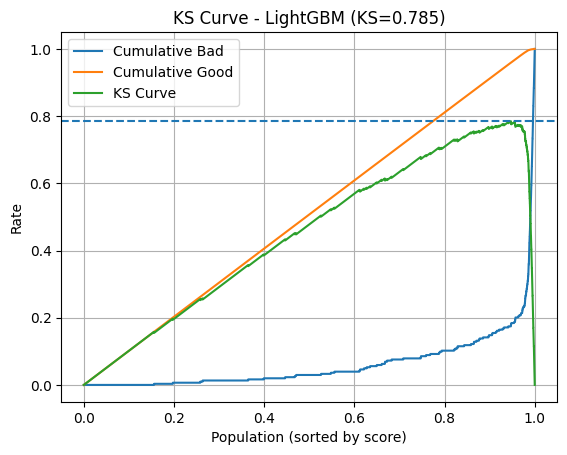

KS = 0.7848


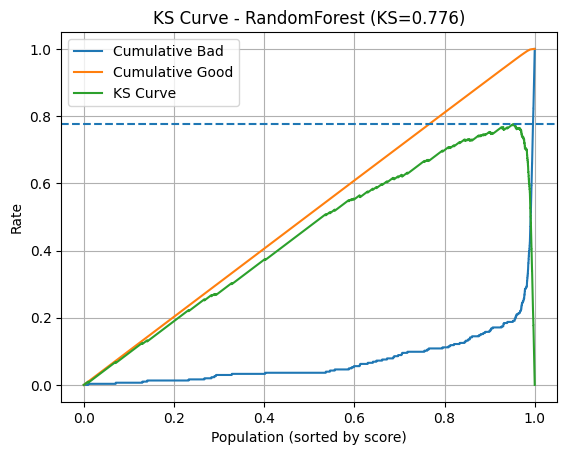

KS = 0.7765


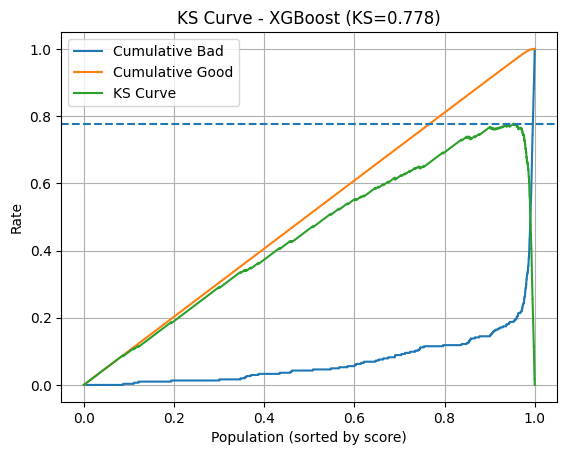

KS = 0.7777


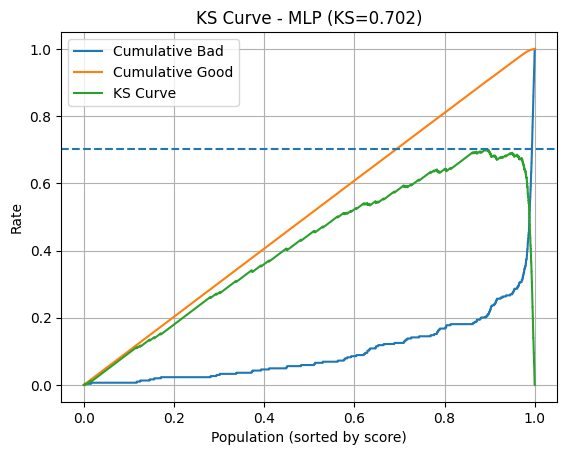

KS = 0.7016


In [ ]:
# LightGBM
pred_lgb = best_lgb.predict_proba(X_test)[:, 1]
plot_ks_curve(y_test, pred_lgb, label="LightGBM")

# RandomForest
pred_rf = best_rf.predict_proba(X_test)[:, 1]
plot_ks_curve(y_test, pred_rf, label="RandomForest")

# XGBoost
pred_xgb = best_xgb.predict_proba(X_test)[:, 1]
plot_ks_curve(y_test, pred_xgb, label="XGBoost")

# MLP
mlp_scaler, mlp_model = best_mlp
pred_mlp = mlp_model.predict_proba(mlp_scaler.transform(X_test))[:, 1]
plot_ks_curve(y_test, pred_mlp, label="MLP")


In [ ]:
lift_lgb = lift_table(y_test, pred_lgb)['lift']
lift_rf  = lift_table(y_test, pred_rf)['lift']
lift_xgb = lift_table(y_test, pred_xgb)['lift']
lift_mlp = lift_table(y_test, pred_mlp)['lift']

deciles = lift_lgb.index.astype(str)


/tmp/ipython-input-245622341.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  table = df.groupby('decile').apply(
/tmp/ipython-input-245622341.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  table = df.groupby('decile').apply(
/tmp/ipython-input-245622341.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas t

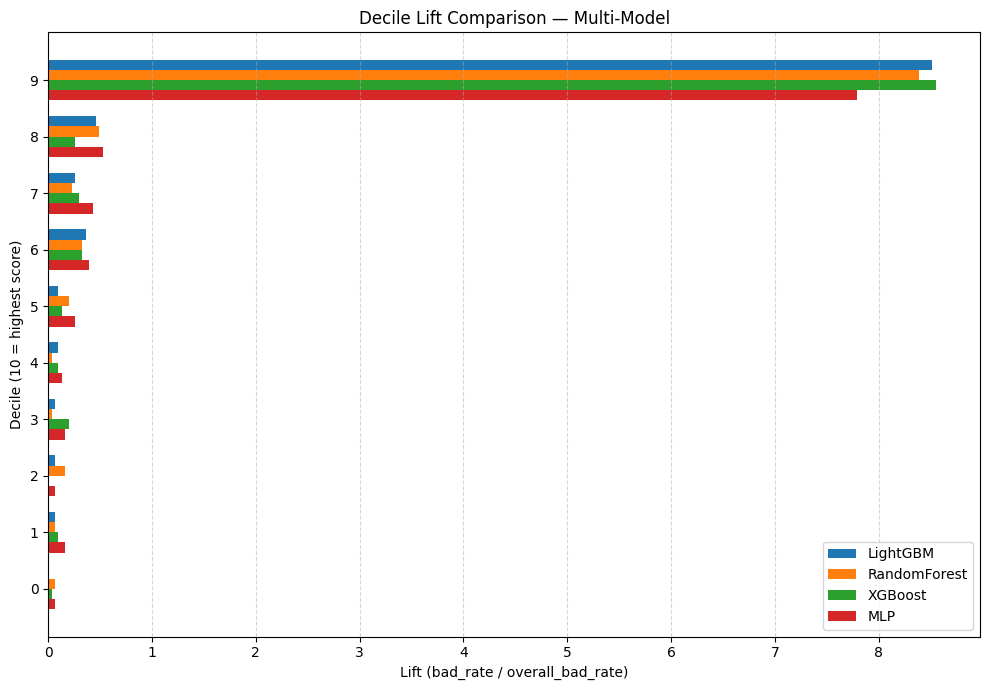

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = ["LightGBM", "RandomForest", "XGBoost", "MLP"]

# 组装二维数组：4 模型 × 10 deciles
lift_matrix = np.vstack([
    lift_lgb.values,
    lift_rf.values,
    lift_xgb.values,
    lift_mlp.values
])

n_models = lift_matrix.shape[0]
n_bins   = lift_matrix.shape[1]

bar_height = 0.18
y = np.arange(n_bins)  # decile 索引 0~9

plt.figure(figsize=(10, 7))

# 每个模型平移一定位置，让柱状图并列
for i in range(n_models):
    plt.barh(
        y + i*bar_height,
        lift_matrix[i],
        height=bar_height,
        label=models[i]
    )

plt.yticks(y + bar_height*1.5, deciles)
plt.xlabel("Lift (bad_rate / overall_bad_rate)")
plt.ylabel("Decile (10 = highest score)")
plt.title("Decile Lift Comparison — Multi-Model")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.legend()
plt.gca().invert_yaxis()  # decile 10 在上

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np

def top10_pct(model, X, model_name, topn=10):
    raw_imp = model.feature_importances_
    df = pd.DataFrame({
        "feature": X.columns,
        "raw_importance": raw_imp
    }).sort_values("raw_importance", ascending=False).head(topn)

    total = df["raw_importance"].sum()
    df["importance_pct"] = df["raw_importance"] / total * 100  # 百分比
    df["importance_pct"] = df["importance_pct"].round(4)

    # 改成多层索引
    df = df[["feature", "importance_pct"]]
    df.columns = pd.MultiIndex.from_product([[model_name], df.columns])

    df.reset_index(drop=True, inplace=True)
    return df


In [ ]:
top_lgb = top10_pct(best_lgb, X_train_full, "LightGBM")
top_rf  = top10_pct(best_rf,  X_train_full, "RandomForest")
top_xgb = top10_pct(best_xgb, X_train_full, "XGBoost")

final_table = pd.concat([top_lgb, top_rf, top_xgb], axis=1)
display(final_table)


LightGBM                 \
                                 feature importance_pct   
0                           credit_score        16.1339   
1       updated_credit_score_1_quarterly        14.5032   
2      original_debt_to_income_dti_ratio        10.3936   
3                       unemp_rate_state        10.3283   
4  estimated_loan_to_value_ltv_quarterly         9.8500   
5                   property_state_avg_y         7.9800   
6                     current_actual_upb         7.9148   
7                 original_interest_rate         7.8930   
8                      seller_name_avg_y         7.6538   
9                    servicer_name_avg_y         7.3494   

                          RandomForest                 \
                               feature importance_pct   
0      current_loan_delinquency_status        24.6472   
1                            has_dq_6m        14.2802   
2                            has_dq_3m        12.0721   
3                           has_dq_12m         9.6259   
4             prev_month_is_delinquent         8.9195   
5                           has_dq_24m         8.5612   
6                    prev_month_status         7.5258   
7     updated_credit_score_1_quarterly         6.0927   
8  distressed_principal_balance_flag_Y         5.2188   
9  distressed_principal_balance_flag_N         3.0567   

                            XGBoost                 
                            feature importance_pct  
0   current_loan_delinquency_status      50.517601  
1                         has_dq_6m      18.462400  
2                        has_dq_12m      12.960400  
3                        has_dq_24m       5.677000  
4             recovered_from_dq_12m       2.529000  
5          prev_month_is_delinquent       2.385600  
6                 prev_month_status       2.317100  
7  updated_credit_score_1_quarterly       1.957900  
8           mortgage_insurance_type       1.852100  
9                    loan_purpose_N       1.340800

In [ ]:
!pip install joblib


In [ ]:
import joblib

# 保存 LightGBM
joblib.dump(best_lgb, "best_lgb.pkl")

# 保存 RandomForest
joblib.dump(best_rf, "best_rf.pkl")

# 保存 XGBoost
joblib.dump(best_xgb, "best_xgb.pkl")

# 保存 MLP + scaler
mlp_scaler, mlp_model = best_mlp
joblib.dump(mlp_scaler, "mlp_scaler.pkl")
joblib.dump(mlp_model, "best_mlp.pkl")

print("All models saved.")


All models saved.
